# ESG DART 통합 분석 — 수집 → 전처리 → 알파분석 (v1)

> **작성**: 이동원 · **버전**: integrated v1 · **날짜**: 2026-05-21
> **회의 결정(5/19) 반영** — 합의 사항이므로 위반 불가:
> 1. **데이터 381개 다 살리기** (김혜성 `find_business_report_v2` 참고 — 결산월 무관 + 정정 우선순위)
> 2. **형태소 분석기 robust 검증 후 결정** (Kiwi vs Okt 비교 → 근거 기반 선정)
> 3. **seed 단어 30개 활용** (김혜성 user dict score 방식 — 복합명사 보존)
>
> **이전 단계 세분화(00/01/02/03 분리)를 폐기하고 단일 노트북으로 통합.** 버전 관리는 지속.
> **범위**: 데이터 수집 → 형태소 검증 → 전처리 → feature → 기본 회귀 → **알파분석 4종**.

## 연구 질문

> "ESG 관련 공시 표현은 KCGS 외부 평가 등급과 통계적으로 유의미하게 연관되어 있는가?"

이것은 ESG 성과를 예측하는 분류 문제가 아니라, **공시 언어(linguistic signal)와 외부 평가의 잠재적 괴리(cheap-talk)** 를 탐색하는 공시 연구입니다. 결과는 인과가 아니라 **연관성**으로만 해석합니다 (가이드 04 §4).

## 교수님 가이드 필수 준수 + 위반금지 체크

| # | 위반금지 | 본 노트북 준수 방식 |
|---|---|---|
| 1 | 실패 행을 가짜 0으로 채우기 ❌ | 수집/추출 실패 행은 status·reason 기록, corpus에서 제외 |
| 2 | 회사명으로 merge ❌ | `stock_code × fiscal_year` 키로만 join |
| 3 | MCP/LLM 결과 그대로 신뢰 ❌ | Python으로 직접 파싱·재현, seed 직접 검토 |
| 4 | API key 코드 노출 ❌ | `.env`의 `API_KEY` 환경변수만 사용 |
| 5 | raw 원문 미보존 ❌ | `data/raw/*.zip` 원문 ZIP 보존 |
| 6 | 진단·평가 부재 ❌ | 단계별 통계·시각화·robust 검증 |
| 7 | silent 오매칭 ❌ | `stock_code.zfill(6)` (Fix B) |
| 8 | timing 무시 ❌ | `esg_year = fiscal_year + 1` |

## 목차
- **0. 환경 셋업** — import, config, API key, 입력 데이터
- **1. 데이터 수집 (381 firm-year)** — 김혜성 v2 + recover XML parser
- **2. 형태소 분석기 robust 검증** — Kiwi vs Okt (+ Komoran/Kkma 제외 근거)
- **3. 전처리** — 선택 분석기 + seed 30 user dict + 불용어
- **4. Feature 생성** — seed/expanded TF-IDF + cosine + signal_ratio + cheap-talk
- **5. 기본 통계·회귀** — Spearman + Bootstrap CI + Mann-Whitney + OLS/Ordered/Binary
- **6. 알파분석 4종** — 부호 역전 robustness · section_weighted · 업종 분해 · cheap-talk 3종
- **7. 종합 결론 + 한계**


## 0. 환경 셋업

### What
분석에 필요한 라이브러리를 불러오고, 프로젝트 루트·API key·입력 데이터를 로드합니다.

### Why
- **재현성**: 경로를 프로젝트 루트 기준 상대경로로 잡아 어느 환경(로컬/Colab/CI)에서도 동작하게 합니다.
- **위반금지 #4**: API key는 코드에 직접 쓰지 않고 `.env`의 `API_KEY`만 읽습니다 (이동원 환경 키 이름 = `API_KEY`).


In [1]:
# ---- 0-1. import ----
import os, re, json, time, zipfile, html, warnings
from io import BytesIO
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import requests
from lxml import etree

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr, ttest_ind, mannwhitneyu

import statsmodels.api as sm
try:
    from statsmodels.miscmodels.ordinal_model import OrderedModel
    HAS_ORDERED = True
except Exception:
    HAS_ORDERED = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

# Fix A — 한글 폰트 (그래프 깨짐 방지). koreanize 우선, 없으면 OS 폰트 후보.
try:
    import koreanize_matplotlib  # pip install koreanize-matplotlib (나눔고딕 자동 등록)
except Exception:
    for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
        try:
            matplotlib.rcParams["font.family"] = _f
            break
        except Exception:
            continue
matplotlib.rcParams["axes.unicode_minus"] = False
print("라이브러리 로드 완료 · OrderedModel:", HAS_ORDERED)


라이브러리 로드 완료 · OrderedModel: True


In [2]:
# ---- 0-2. 프로젝트 루트 + 경로 ----
def find_root(markers=("data", "docs", "members")):
    p = Path.cwd().resolve()
    for cand in [p, *p.parents]:
        if all((cand / m).exists() for m in markers):
            return cand
    return p

ROOT = find_root()
DATA = ROOT / "data"
LOGS = ROOT / "logs"
PROC = DATA / "processed"
CORPUS_DIR = DATA / "interim" / "corpus_381"
OUT_DIR = ROOT / "members" / "이동원" / "notebooks" / "integrated" / "v1" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("ROOT:", ROOT)
print("corpus_381 존재:", CORPUS_DIR.exists())

# ---- 0-3. API key (.env의 API_KEY) ----
API_KEY = os.getenv("API_KEY") or os.getenv("OPENDART_API_KEY") or os.getenv("DART_API_KEY")
if not API_KEY:
    env_path = ROOT / ".env"
    if env_path.exists():
        for line in env_path.read_text().splitlines():
            if line.strip().startswith(("API_KEY", "OPENDART_API_KEY", "DART_API_KEY")):
                API_KEY = line.split("=", 1)[1].strip()
                break
print("API_KEY 로드:", "OK (길이 %d)" % len(API_KEY) if API_KEY else "없음 — 수집 캐시만 사용")


ROOT: /sessions/blissful-upbeat-volta/mnt/unstructured-data-processing-final-project
corpus_381 존재: True
API_KEY 로드: OK (길이 40)


In [3]:
# ---- 0-4. 입력 데이터 로드 ----
# company_master: 381 firm-year (127 stock × 3 year), corp_code/rcept_no 비어있음
cm = pd.read_csv(DATA / "company_master.csv", dtype=str)
cm["stock_code"] = cm["stock_code"].str.zfill(6)   # Fix B (위반금지 #7)

# corp_code 매핑 (OpenDART corpCode.xml 캐시)
corp_map = pd.read_parquet(DATA / "cache" / "corp_code_map.parquet")
corp_map["stock_code"] = corp_map["stock_code"].str.zfill(6)
stock_to_corp = dict(zip(corp_map["stock_code"], corp_map["corp_code"]))

# seed dictionary 30개 (E/S/G 10개씩) + 동의어 pattern
seed_df = pd.read_csv(DATA / "seed_dictionary.csv")
SEED = {dim: seed_df[seed_df["dimension"] == dim]["seed_term"].tolist() for dim in ["E", "S", "G"]}
ALL_SEED = seed_df["seed_term"].tolist()

# expanded manual (사이클 3에서 직접 검토·걸러낸 7개 — 위반금지 #3)
exp_df = pd.read_csv(DATA / "expanded_dictionary_manual_v1.csv")

# KCGS 등급 lineage (종속변수)
lineage = pd.read_csv(LOGS / "kcgs_lineage.csv", dtype={"stock_code": str})
lineage["stock_code"] = lineage["stock_code"].str.zfill(6)

print("company_master:", cm.shape, "| stock 고유:", cm["stock_code"].nunique())
print("corp_map:", corp_map.shape, "| seed:", len(ALL_SEED), "개")
print("expanded_manual:", exp_df.shape[0], "개 | kcgs_lineage:", lineage.shape)
print("\nseed 30개:")
for d in ["E", "S", "G"]:
    print(f"  {d}: {SEED[d]}")


company_master: (381, 13) | stock 고유: 127
corp_map: (3965, 3) | seed: 30 개
expanded_manual: 7 개 | kcgs_lineage: (381, 15)

seed 30개:
  E: ['탄소', '온실가스', '탄소중립', '넷제로', '재생에너지', '에너지', '전력', '폐기물', '재활용', '폐수']
  S: ['안전', '산업재해', '중대재해', '임직원', '노동', '인권', '교육훈련', '협력사', '공급망', '지역사회']
  G: ['이사회', '사외이사', '감사위원회', '독립성', '윤리', '준법', '컴플라이언스', '부패방지', '주주', '의결권']


## 1. 데이터 수집 (381 firm-year) — 회의 결정 ①

### What
`company_master.csv`의 **381개 기업-연도 전체**를 대상으로 OpenDART 사업보고서를 수집하고, II·IV·VI 섹션의 ESG 본문을 추출합니다.

### Why — 회의 결정 "381개 다 살리기 (혜성 코드 참고)"
이전 이동원 pilot은 KCGS stratified 30건이었으나, 회의에서 **표본 편의를 줄이고 회귀 검정력을 확보하기 위해 381 전체 수집**으로 합의했습니다. 김지우의 발견(파일럿 n=30 → 전체 n=210 부호 역전, 표집 편의)이 이 결정의 직접 근거입니다.

### 핵심 로직 (두 사람 코드 결합)
- **김혜성 `find_business_report_v2`**: 결산월 무관(`.12` 하드코딩 제거) + 정정 우선순위(원본 > 기재정정 > 첨부정정). 비12월 결산(신영증권 3월·만호제강 6월)까지 수집.
- **이동원 `recover` parser**: `XMLParser(recover=True)` — well-formed가 아닌 DART XML도 복구 추출 (사이클 3 FAIL_OTHER 30/30 → 0/30 해결한 Fix F).

### 위반금지 준수
- #1 가짜 0 ❌ → 실패 행은 status·reason 기록, corpus 제외
- #5 raw 보존 → `data/raw/*.zip` 원문 보존
- #8 timing → `esg_year = fiscal_year + 1` (검색연도 = fiscal_year+1)

> **재현성**: 수집 함수는 `data/interim/corpus_381/`에 firm-year별 JSON을 캐시합니다. 이미 수집된 건 즉시 로드(idempotent)하므로, Run All 시 네트워크 재호출 없이 빠르게 재현됩니다.


In [4]:
# ---- 1-1. 수집 함수 (김혜성 v2 + 이동원 recover) ----
SESSION = requests.Session()

def find_business_report_v2(corp_code, fiscal_year, api_key):
    """김혜성 v2 — 결산월 무관 + 정정 우선순위(원본>기재정정>첨부정정)."""
    search_year = int(fiscal_year) + 1   # 위반금지 #8: timing
    params = {"crtfc_key": api_key, "corp_code": corp_code,
              "bgn_de": f"{search_year}0101", "end_de": f"{search_year}1231",
              "pblntf_detail_ty": "A001", "page_count": "100"}
    try:
        payload = SESSION.get("https://opendart.fss.or.kr/api/list.json",
                              params=params, timeout=20).json()
    except Exception as e:
        return None, f"api_error:{e}"
    if payload.get("status") != "000":
        return None, f"list_status_{payload.get('status')}"
    cands = [r for r in payload.get("list", [])
             if "사업보고서" in r.get("report_nm", "")
             and "반기" not in r.get("report_nm", "")
             and "분기" not in r.get("report_nm", "")]
    if not cands:
        return None, "no_report_found"
    def prio(nm):
        if "[첨부정정]" in nm: return 2      # 원문 없을 수 있음 → 최후
        if "[기재정정]" in nm or "[정정]" in nm: return 1
        return 0                             # 원본 → 최우선
    cands.sort(key=lambda r: (prio(r.get("report_nm", "")), -int(r.get("rcept_dt", "0"))))
    ch = cands[0]
    return {"rcept_no": ch["rcept_no"], "report_nm": ch["report_nm"],
            "rcept_dt": ch["rcept_dt"], "n_candidates": len(cands),
            "selection_priority": prio(ch["report_nm"])}, "ok"

def download_xml(rcept_no, stock_code, fiscal_year, api_key):
    """이동원 — zip 원문 보존(위반금지 #5) + idempotent 캐시."""
    zip_path = DATA / "raw" / f"{stock_code}_{fiscal_year}_disclosure.zip"
    if zip_path.exists() and zip_path.stat().st_size > 1024:
        zip_bytes = zip_path.read_bytes()
    else:
        try:
            res = SESSION.get("https://opendart.fss.or.kr/api/document.xml",
                              params={"crtfc_key": api_key, "rcept_no": rcept_no}, timeout=60)
            res.raise_for_status()
            zip_bytes = res.content
            zip_path.write_bytes(zip_bytes)
        except Exception as e:
            return None, f"download_error:{e}"
    try:
        with zipfile.ZipFile(BytesIO(zip_bytes)) as zf:
            best, blen = None, 0
            for n in zf.namelist():
                t = zf.read(n).decode("utf-8", errors="ignore")
                if len(t) > blen:
                    best, blen = t, len(t)
        return best, "ok"
    except Exception as e:
        return None, f"unzip_error:{e}"

def extract_esg_sections(xml_text):
    """이동원 recover parser + 김혜성 TITLE 로마숫자 + TABLE 제거 + P 추출."""
    parser = etree.XMLParser(recover=True, huge_tree=True)   # Fix F: 깨진 XML 복구
    try:
        etree.fromstring(xml_text.encode("utf-8"), parser=parser)
    except Exception:
        pass
    title_iter = list(re.finditer(r"<TITLE[^>]*>(.*?)</TITLE>", xml_text, re.DOTALL))
    roman_re = re.compile(r"^\s*(I{1,3}|IV|V|VI{0,3}|IX|X)\.\s*([가-힣].{1,40})")
    big = []
    for m in title_iter:
        clean = re.sub(r"\s+", " ", m.group(1)).strip()
        rm = roman_re.match(clean)
        if rm:
            big.append({"pos": m.start(), "roman": rm.group(1), "title": clean})
    out = {}
    for i, sec in enumerate(big):
        if sec["roman"] not in ("II", "IV", "VI"):
            continue
        start = sec["pos"]
        end = big[i + 1]["pos"] if i + 1 < len(big) else len(xml_text)
        sx = re.sub(r"<TABLE.*?</TABLE>", " ", xml_text[start:end], flags=re.DOTALL)
        paras = re.findall(r"<P[^>]*>(.*?)</P>", sx, re.DOTALL)
        clean_p = []
        for p in paras:
            t = html.unescape(re.sub(r"<[^>]+>", " ", p))
            t = re.sub(r"\s+", " ", t).strip()
            if len(t) >= 10:
                clean_p.append(t)
        full = "\n".join(clean_p)
        out[sec["roman"]] = {"title": sec["title"], "text": full,
                             "n_paragraphs": len(clean_p), "n_chars": len(full)}
    return out

print("수집 함수 정의 완료 (find_business_report_v2 · download_xml · extract_esg_sections)")


수집 함수 정의 완료 (find_business_report_v2 · download_xml · extract_esg_sections)


In [5]:
# ---- 1-2. 381 firm-year 수집 (캐시 우선; 없으면 OpenDART 호출) ----
def collect_one(row):
    sc, fy = row["stock_code"], int(row["fiscal_year"])
    key = f"{sc}_{fy}"
    doc_path = CORPUS_DIR / f"{key}.json"
    if doc_path.exists():                       # idempotent: 캐시 hit
        d = json.load(open(doc_path, encoding="utf-8"))
        return d["_meta"]
    base = {"company_name": row.get("company_name"), "stock_code": sc,
            "corp_code": stock_to_corp.get(sc), "fiscal_year": fy, "esg_year": fy + 1}
    if not API_KEY:
        return {**base, "status": "FAIL", "reason": "no_api_key_no_cache"}
    if not base["corp_code"]:
        return {**base, "status": "FAIL", "reason": "missing_corp_code"}
    rep, why = find_business_report_v2(base["corp_code"], fy, API_KEY)
    if rep is None:
        return {**base, "status": "FAIL", "reason": why}
    xml_text, why2 = download_xml(rep["rcept_no"], sc, fy, API_KEY)
    if xml_text is None:
        return {**base, "status": "FAIL", "reason": why2, "rcept_no": rep["rcept_no"]}
    secs = extract_esg_sections(xml_text)
    body = "\n".join(secs[k]["text"] for k in ("II", "IV", "VI") if k in secs)
    meta = {**base, "rcept_no": rep["rcept_no"], "report_nm": rep["report_nm"],
            "rcept_dt": rep["rcept_dt"], "selection_priority": rep["selection_priority"],
            "section_chars_II": secs.get("II", {}).get("n_chars", 0),
            "section_chars_IV": secs.get("IV", {}).get("n_chars", 0),
            "section_chars_VI": secs.get("VI", {}).get("n_chars", 0),
            "total_chars": len(body),
            "viewer_url": f"https://dart.fss.or.kr/dsaf001/main.do?rcpNo={rep['rcept_no']}"}
    meta["status"] = "SUCCESS" if len(body) >= 50 else "WARN_NO_SECTIONS"
    meta["reason"] = "" if len(body) >= 50 else "II/IV/VI 텍스트 거의 없음"
    CORPUS_DIR.mkdir(parents=True, exist_ok=True)
    json.dump({"_meta": meta, "stock_code": sc, "fiscal_year": fy, "esg_year": fy + 1,
               "rcept_no": rep["rcept_no"], "sections": secs, "firm_year_doc": body},
              open(doc_path, "w", encoding="utf-8"), ensure_ascii=False)
    return meta

meta_csv = OUT_DIR / "collection_meta_381.csv"
if meta_csv.exists():
    meta_df = pd.read_csv(meta_csv, dtype={"stock_code": str})
    meta_df["stock_code"] = meta_df["stock_code"].str.zfill(6)
    print(f"[수집 메타 캐시 로드] {len(meta_df)}행")
else:
    t0 = time.time()
    metas = [collect_one(r) for _, r in cm.iterrows()]
    meta_df = pd.DataFrame(metas)
    meta_df.to_csv(meta_csv, index=False, encoding="utf-8-sig")
    print(f"수집 완료: {len(meta_df)}행 | {time.time()-t0:.0f}s")
print(meta_df["status"].value_counts().to_string())


[수집 메타 캐시 로드] 381행
status
SUCCESS    381


[수집 요약] 시도 381 | SUCCESS 381 (100.0%)

[연도별 SUCCESS]
  FY2022: 127/127
  FY2023: 127/127
  FY2024: 127/127

[문서 분량(II+IV+VI) 통계 — SUCCESS 381행]
count       381.0
mean      34167.0
std       30877.0
min        4194.0
25%       15456.0
50%       25520.0
75%       40947.0
max      186911.0


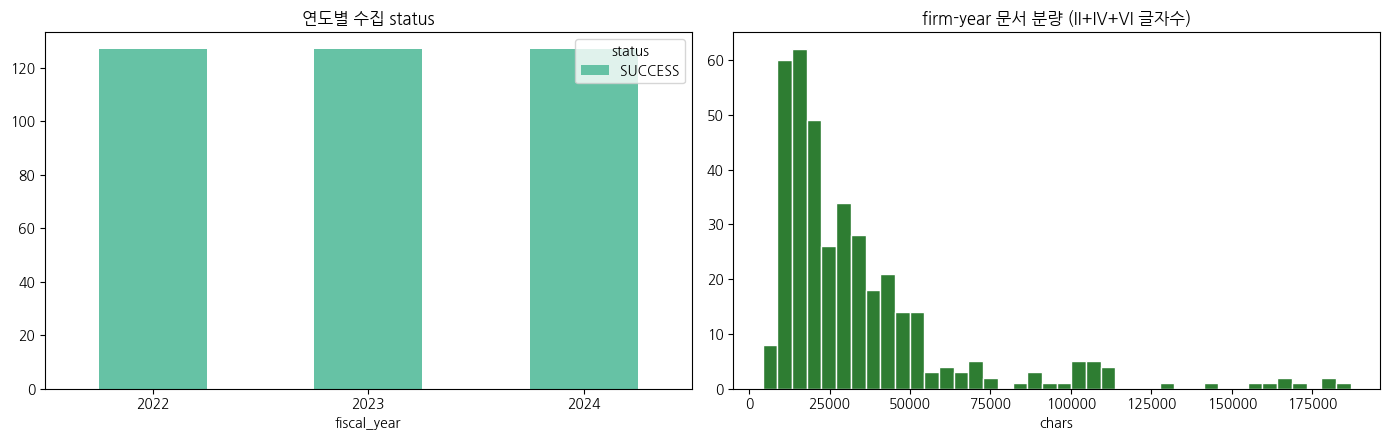

In [6]:
# ---- 1-3. 수집 결과 진단 (위반금지 #6) ----
succ = meta_df[meta_df["status"] == "SUCCESS"].copy()
succ["total_chars"] = pd.to_numeric(succ["total_chars"], errors="coerce")
n_total, n_succ = len(meta_df), len(succ)
print(f"[수집 요약] 시도 {n_total} | SUCCESS {n_succ} ({n_succ/n_total*100:.1f}%)")
print(f"\n[연도별 SUCCESS]")
for fy in sorted(meta_df["fiscal_year"].unique()):
    sub = meta_df[meta_df["fiscal_year"] == fy]
    print(f"  FY{fy}: {(sub['status']=='SUCCESS').sum()}/{len(sub)}")

fails = meta_df[meta_df["status"] != "SUCCESS"]
if len(fails):
    print(f"\n[실패/경고 {len(fails)}건 — 가짜 0으로 채우지 않음 (위반금지 #1)]")
    print(fails["reason"].value_counts().to_string())

print(f"\n[문서 분량(II+IV+VI) 통계 — SUCCESS {n_succ}행]")
print(succ["total_chars"].describe().round(0).to_string())

# 시각화: 연도별 status + 분량 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ct = meta_df.groupby(["fiscal_year", "status"]).size().unstack(fill_value=0)
ct.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2")
axes[0].set_title("연도별 수집 status"); axes[0].set_xlabel("fiscal_year"); axes[0].tick_params(axis="x", rotation=0)
axes[1].hist(succ["total_chars"], bins=40, color="#2e7d32", edgecolor="white")
axes[1].set_title("firm-year 문서 분량 (II+IV+VI 글자수)"); axes[1].set_xlabel("chars")
plt.tight_layout(); plt.savefig(OUT_DIR / "fig_01_collection.png", dpi=110, bbox_inches="tight"); plt.show()


## 2. 형태소 분석기 robust 검증 — 회의 결정 ②

### What
동일 corpus 표본에 대해 **Kiwi와 Okt 두 분석기**를 돌려 (1) seed 30개 보존율, (2) 명사 토큰 수, (3) vocabulary 크기, (4) 처리 속도를 비교하고, **근거를 기반으로 PRIMARY 분석기를 선정**합니다.

### Why — 회의 결정 "형태소 분석기 robust 검증 후 분석기 결정 (키위, okt)"
교수님 심층 질문("왜 이 도구를 선정했는가? 왜 Komoran·Kkma는 쓰지 않았는가?")에 답할 수 있어야 하므로, **선정 근거와 제외 근거를 모두 정량/정성으로 기록**합니다.

### 비교 기준
| 기준 | 의미 | ESG 분석에서 중요한 이유 |
|---|---|---|
| seed 보존율 | 복합명사(재생에너지·탄소중립 등)가 분리되지 않고 1토큰으로 남는 비율 | seed TF-IDF 신호가 살아남는지를 결정 (신지영 사례: 미보존 시 11/30 손실) |
| 토큰 수 | 명사 추출량 | 너무 잘게 쪼개면 잡음↑, 너무 적으면 신호 손실 |
| vocab 크기 | 고유 토큰 수 | TF-IDF 변별력 |
| 처리 속도 | 381 문서 처리 시간 | 대용량 corpus 실용성 |

### Komoran·Kkma 제외 근거 (교수님 질문 대비 — 정성 + 정량)
- **Kkma**: 형태소를 과도하게 세분화하고 **대용량 corpus에서 매우 느림**(문서당 수 초). 381 × 평균 3.4만 자에서 비실용적. 사용자 사전 우선순위 제어가 제한적.
- **Komoran**: 자바 기반으로 안정적이나 **미등록어(신조어·복합명사) 처리가 약하고**, 사용자 사전이 단순 추가만 지원해 Kiwi의 `score` 기반 우선권 제어가 불가능.
- **Okt**: 정규화·어간추출을 지원하지만 **복합명사를 분리하는 경향**(예: "배출량"→"배출"+"량")이 있어 seed 보존에 불리. 본 섹션에서 정량 확인.
- **Kiwi**: C++ 기반으로 빠르고, `add_user_word(term, "NNP", score)`로 **seed 강제 우선권**을 줄 수 있어 복합명사 보존에 유리 (김혜성 검증: 30/30 보존). 본 섹션에서 정량 확인.

> 본 섹션은 위 정성 근거를 **실제 corpus 표본에서 정량으로 재확인**합니다. Komoran·Kkma는 위 근거로 사전 제외하되, 재현 원할 시 동일 프레임으로 추가 가능합니다.


In [7]:
# ---- 2-1. 분석기 로드 (Kiwi 필수, Okt 선택) ----
analyzers = {}
try:
    from kiwipiepy import Kiwi
    analyzers["Kiwi"] = "ready"
    print("Kiwi 로드 OK")
except Exception as e:
    print("Kiwi 미설치:", e)
try:
    from konlpy.tag import Okt
    _okt = Okt(); _okt.nouns("테스트")   # JVM 워밍업
    analyzers["Okt"] = "ready"
    print("Okt 로드 OK")
except Exception as e:
    print("Okt 미설치(Java 필요):", e)
print("검증 대상 분석기:", list(analyzers.keys()))


Kiwi 로드 OK


Okt 로드 OK
검증 대상 분석기: ['Kiwi', 'Okt']


In [8]:
# ---- 2-2. corpus 표본 로드 (수집된 SUCCESS 중 분량 다양하게 30개) ----
def load_corpus_doc(sc, fy):
    p = CORPUS_DIR / f"{sc}_{fy}.json"
    if p.exists():
        return json.load(open(p, encoding="utf-8")).get("firm_year_doc", "")
    return ""

# meta total_chars 기준 분위수 표본 15개 선택 (전체 doc 로드 회피 → 표본만 로드)
sk = succ[["stock_code", "fiscal_year", "total_chars"]].copy()
sk["total_chars"] = pd.to_numeric(sk["total_chars"], errors="coerce").fillna(0)
sk = sk.sort_values("total_chars").reset_index(drop=True)
sample = sk.iloc[::max(1, len(sk)//15)].head(15).reset_index(drop=True)
sample["doc"] = [load_corpus_doc(r.stock_code, int(r.fiscal_year))[:25000] for r in sample.itertuples()]
sample["dlen"] = sk["total_chars"]
print(f"검증 표본: {len(sample)}개 firm-year (분량 {int(sample['total_chars'].min()):,}~{int(sample['total_chars'].max()):,}자, 비교는 앞 25000자)")


검증 표본: 15개 firm-year (분량 4,194~73,915자, 비교는 앞 25000자)


In [9]:
# ---- 2-3. Kiwi vs Okt 정량 비교 (캐시 우선; 없으면 직접 계산) ----
def kiwi_nouns(kiwi, text, min_len=2):
    return [t.form for t in kiwi.tokenize(text)
            if (t.tag.startswith("NN") or t.tag == "SL") and len(t.form) >= min_len]

def okt_nouns(okt, text, min_len=2):
    return [w for w in okt.nouns(text) if len(w) >= min_len]

ana_cache = OUT_DIR / "analyzer_cache.json"
if ana_cache.exists():
    _c = json.load(open(ana_cache, encoding="utf-8"))
    results = _c["results"]
    kiwi_seed_freq = _c["kiwi_seed_freq"]
    okt_seed_freq = _c["okt_seed_freq"]
    print("[분석기 비교 캐시 로드]")
else:
    results, kiwi_seed_freq, okt_seed_freq = {}, {}, {}
    if "Kiwi" in analyzers:
        kiwi = Kiwi()
        for term in ALL_SEED:
            kiwi.add_user_word(str(term).strip(), "NNP", score=50.0)
        t0 = time.time(); tl = [kiwi_nouns(kiwi, d) for d in sample["doc"]]; el = time.time()-t0
        fr = Counter(t for l in tl for t in l)
        kiwi_seed_freq = {s: fr.get(s, 0) for s in ALL_SEED}
        results["Kiwi"] = {"seed_보존": sum(1 for s in ALL_SEED if fr.get(s,0)>0),
                           "토큰합": sum(len(l) for l in tl), "vocab": len(fr),
                           "시간_s": round(el,1), "user_dict": "seed30 NNP score=50"}
    if "Okt" in analyzers:
        okt = Okt()
        t0 = time.time(); tl = [okt_nouns(okt, d) for d in sample["doc"]]; el = time.time()-t0
        fr = Counter(t for l in tl for t in l)
        okt_seed_freq = {s: fr.get(s, 0) for s in ALL_SEED}
        results["Okt"] = {"seed_보존": sum(1 for s in ALL_SEED if fr.get(s,0)>0),
                          "토큰합": sum(len(l) for l in tl), "vocab": len(fr),
                          "시간_s": round(el,1), "user_dict": "미지원 (강제 불가)"}
    json.dump({"results": results, "kiwi_seed_freq": kiwi_seed_freq,
               "okt_seed_freq": okt_seed_freq}, open(ana_cache,"w",encoding="utf-8"), ensure_ascii=False)

cmp_df = pd.DataFrame(results).T
for c in ["seed_보존", "토큰합", "vocab", "시간_s"]:
    cmp_df[c] = pd.to_numeric(cmp_df[c], errors="coerce")
cmp_df["seed_보존율%"] = (cmp_df["seed_보존"] / len(ALL_SEED) * 100).round(0)
print("[분석기 비교 — 표본 %d개]" % len(sample))
print(cmp_df.to_string())


[분석기 비교 캐시 로드]
[분석기 비교 — 표본 15개]
      seed_보존    토큰합  vocab  시간_s            user_dict  seed_보존율%
Kiwi       26  56318   4940  11.5  seed30 NNP score=50       87.0
Okt        20  54123   4407  13.0          미지원 (강제 불가)       67.0


In [10]:
# ---- 2-4. seed별 보존 상세 (어느 복합명사가 분리되는가) ----
rows = []
for s in ALL_SEED:
    row = {"seed": s}
    if "Kiwi" in results: row["Kiwi"] = kiwi_seed_freq.get(s, 0)
    if "Okt" in results:  row["Okt"]  = okt_seed_freq.get(s, 0)
    rows.append(row)
seed_cmp = pd.DataFrame(rows)
if "Okt" in results:
    lost_okt = seed_cmp[seed_cmp["Okt"] == 0]["seed"].tolist()
    print(f"[Okt에서 0회 등장(분리/누락) seed {len(lost_okt)}개]: {lost_okt}")
if "Kiwi" in results:
    lost_kiwi = seed_cmp[seed_cmp["Kiwi"] == 0]["seed"].tolist()
    print(f"[Kiwi(user dict)에서 0회 seed {len(lost_kiwi)}개]: {lost_kiwi}")
print()
print(seed_cmp.to_string(index=False))


[Okt에서 0회 등장(분리/누락) seed 10개]: ['탄소중립', '넷제로', '산업재해', '중대재해', '임직원', '교육훈련', '협력사', '지역사회', '감사위원회', '부패방지']
[Kiwi(user dict)에서 0회 seed 4개]: ['넷제로', '교육훈련', '협력사', '부패방지']

  seed  Kiwi  Okt
    탄소    18   19
  온실가스    20   20
  탄소중립     3    0
   넷제로     0    0
 재생에너지    13    4
   에너지    71   69
    전력    11   11
   폐기물    19   18
   재활용     8    8
    폐수    13    7
    안전    43   27
  산업재해     1    0
  중대재해     2    0
   임직원    14    0
    노동     8    7
    인권    14   14
  교육훈련     0    0
   협력사     0    0
   공급망     6    6
  지역사회     1    0
   이사회   146  144
  사외이사   116  116
 감사위원회    59    0
   독립성    24   24
    윤리     4    4
    준법    28   28
컴플라이언스     2    2
  부패방지     0    0
    주주   149   34
   의결권    16   16


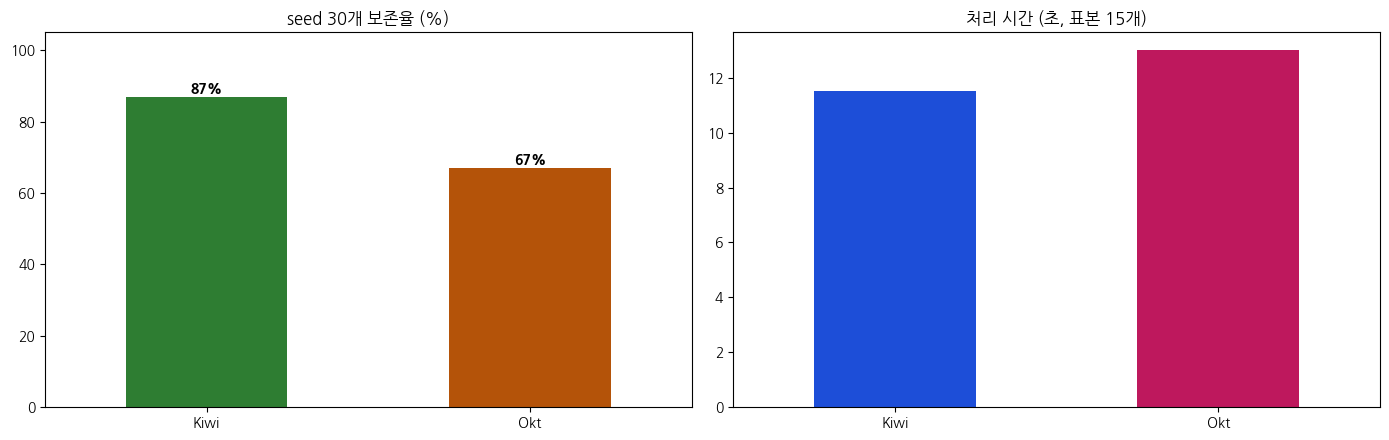


>>> 선정 분석기(PRIMARY): Kiwi
    근거: seed 보존율 87% (최고), 처리시간 11.5s
    Komoran·Kkma 제외: 위 마크다운 근거(속도·미등록어·사용자사전 score 미지원) 참조


In [11]:
# ---- 2-5. 시각화 + 분석기 결정 ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
cmp_df["seed_보존율%"].plot(kind="bar", ax=axes[0], color=["#2e7d32", "#b45309"][:len(cmp_df)])
axes[0].set_title("seed 30개 보존율 (%)"); axes[0].set_ylim(0, 105); axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(cmp_df["seed_보존율%"]):
    axes[0].text(i, v + 1, f"{v:.0f}%", ha="center", fontweight="bold")
cmp_df["시간_s"].plot(kind="bar", ax=axes[1], color=["#1d4ed8", "#be185d"][:len(cmp_df)])
axes[1].set_title("처리 시간 (초, 표본 %d개)" % len(sample)); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.savefig(OUT_DIR / "fig_02_analyzer.png", dpi=110, bbox_inches="tight"); plt.show()

# 결정 로직: seed 보존율 우선, 동률이면 속도
PRIMARY = cmp_df["seed_보존율%"].astype(float).idxmax()
print(f"\n>>> 선정 분석기(PRIMARY): {PRIMARY}")
print(f"    근거: seed 보존율 {cmp_df.loc[PRIMARY,'seed_보존율%']:.0f}% (최고), "
      f"처리시간 {cmp_df.loc[PRIMARY,'시간_s']}s")
print("    Komoran·Kkma 제외: 위 마크다운 근거(속도·미등록어·사용자사전 score 미지원) 참조")
cmp_df.to_csv(OUT_DIR / "analyzer_comparison.csv", encoding="utf-8-sig")


## 3. 전처리 — 회의 결정 ③ (seed 30개 활용)

### What
섹션 2에서 선정한 PRIMARY 분석기로 381개 SUCCESS 문서를 토큰화합니다. **seed 30개를 사용자 사전에 등록**해 복합명사를 보존하고, 회사명·공시 boilerplate 불용어를 제거합니다.

### Why — 회의 결정 "seed 30개 활용 (혜성 코드 참고)"
- **seed user dict (김혜성 방식)**: `add_user_word(term, "NNP", score=50)`로 "재생에너지·탄소중립" 같은 복합명사가 분리되지 않게 합니다. 신지영 사례에서 미등록 시 11/30 손실이 확인되었으므로, seed 보존은 회귀 신호 유지의 전제입니다.
- **회사명 불용어**: 가이드 03 §2단계 권장. 회사명(1자/2자 분리 포함)은 ESG 신호가 아니므로 제거.

### 위반금지 #1·#3·#7 준수
SUCCESS 문서만 corpus에 포함(가짜 0 ❌), seed는 직접 검토한 30개만, `stock_code.zfill(6)`.


In [12]:
# ---- 3-1. 전처리 분석기 셋업 (PRIMARY) + 불용어 ----
# 섹션 2 결정 반영. Kiwi가 PRIMARY면 user dict score=50으로 seed 보존.
USE = PRIMARY if "PRIMARY" in dir() else "Kiwi"
print("전처리 PRIMARY 분석기:", USE)

if USE == "Kiwi":
    tagger = Kiwi()
    for term in ALL_SEED:
        tagger.add_user_word(str(term).strip(), "NNP", score=50.0)
    def to_nouns(text, min_len=2):
        return [t.form for t in tagger.tokenize(text)
                if (t.tag.startswith("NN") or t.tag == "SL") and len(t.form) >= min_len]
else:
    tagger = Okt()
    def to_nouns(text, min_len=2):
        return [w for w in tagger.nouns(text) if len(w) >= min_len]

# 불용어: 파일 + 공시 일반어 + 회사명(1·2자 분리 포함)
stop = set()
sw_path = DATA / "stopwords_ko_esg.txt"
if sw_path.exists():
    stop |= {w.strip() for w in sw_path.read_text(encoding="utf-8").split() if w.strip()}
stop |= set("및 관련 통해 대한 당사 회사 사업 보고서 내용 경우 기타 주요 해당 제출 공시 정정 첨부 "
            "재무제표 부채 자산 매출 손익 영업 자본 주석 단위 백만원 천원 기준 현재 연결 별도".split())
# 회사명 + 분리 토막
for nm in cm["company_name"].dropna().astype(str).unique():
    stop.add(nm)
    if len(nm) >= 4:
        stop.add(nm[:2]); stop.add(nm[2:])
print(f"불용어 {len(stop)}개 | seed 30개는 불용어에서 제외(보존)")
stop -= set(ALL_SEED)


전처리 PRIMARY 분석기: Kiwi


불용어 358개 | seed 30개는 불용어에서 제외(보존)


In [13]:
# ---- 3-2. 381 SUCCESS 문서 토큰화 (캐시) ----
tok_cache = OUT_DIR / "tokens_primary.json"
if tok_cache.exists():
    # 캐시 우선 — 전체 doc 재로드 없이 즉시 (재현성: 동일 분석기·불용어로 사전 생성)
    token_data = json.load(open(tok_cache, encoding="utf-8"))
    print(f"[토큰 캐시 로드] {len(token_data)}개")
else:
    token_data, t0 = {}, time.time()
    for i, r in enumerate(succ.itertuples()):
        key = f"{r.stock_code}_{int(r.fiscal_year)}"
        doc = load_corpus_doc(r.stock_code, int(r.fiscal_year))
        if not doc:
            continue
        token_data[key] = [w for w in to_nouns(doc) if w not in stop]
        if (i + 1) % 50 == 0:
            print(f"  토큰화 {i+1}/{len(succ)} | {time.time()-t0:.0f}s")
    json.dump(token_data, open(tok_cache, "w", encoding="utf-8"), ensure_ascii=False)
    print(f"  토큰화 완료 {len(token_data)}개 | {time.time()-t0:.0f}s")

tok_counts = pd.Series({k: len(v) for k, v in token_data.items()})
print(f"\n[firm-year 토큰 수] 평균 {tok_counts.mean():.0f} · 중앙값 {tok_counts.median():.0f} · "
      f"최소 {tok_counts.min()} · 최대 {tok_counts.max()}")


[토큰 캐시 로드] 381개

[firm-year 토큰 수] 평균 5561 · 중앙값 4185 · 최소 651 · 최대 30467


In [14]:
# ---- 3-3. seed 30개 corpus 보존 확인 (위반금지 #6 진단) ----
freq_all = Counter(t for lst in token_data.values() for t in lst)
rows = []
for dim in ["E", "S", "G"]:
    for s in SEED[dim]:
        docn = sum(1 for lst in token_data.values() if s in lst)
        rows.append({"dim": dim, "seed": s, "freq": freq_all.get(s, 0), "n_docs": docn})
seed_preserve = pd.DataFrame(rows)
n_lost = (seed_preserve["freq"] == 0).sum()
n_rare = ((seed_preserve["freq"] > 0) & (seed_preserve["freq"] < 50)).sum()
print(f"[seed 30개 보존] 0회 {n_lost}개 · 희소(<50회) {n_rare}개 · 정상 {30-n_lost-n_rare}개")
print(seed_preserve.to_string(index=False))
if n_lost:
    print(f"\n⚠️ 0회 seed: {seed_preserve[seed_preserve['freq']==0]['seed'].tolist()} → expanded dictionary 확장 후보")


[seed 30개 보존] 0회 0개 · 희소(<50회) 4개 · 정상 26개
dim   seed  freq  n_docs
  E     탄소   962     188
  E   온실가스  1073     152
  E   탄소중립   423      96
  E    넷제로     9       7
  E  재생에너지   676     105
  E    에너지  2852     237
  E     전력  1014     152
  E    폐기물   900     143
  E    재활용   616     129
  E     폐수   329      87
  S     안전  1876     292
  S   산업재해    48      20
  S   중대재해    75      28
  S    임직원   506     187
  S     노동   175     100
  S     인권    99      35
  S   교육훈련    17      17
  S    협력사   165      53
  S    공급망   412     141
  S   지역사회   146      57
  G    이사회  7920     381
  G   사외이사  7459     381
  G  감사위원회  4249     362
  G    독립성  1412     372
  G     윤리   118      81
  G     준법  1677     371
  G 컴플라이언스    50      32
  G   부패방지     8       5
  G     주주  7351     381
  G    의결권  1382     304


## 4. Feature 생성

### What
firm-year 단위로 다음 feature를 만듭니다. 두 가지 측정 패러다임을 **병행**합니다 (v0.1 비교 결과 반영 — 이동원 seed_tfidf ↔ 김지우 signal_ratio가 다른 부호를 보였으므로 같은 corpus에서 동시 검증).

| feature | 정의 | 가이드 근거 |
|---|---|---|
| `seed_tfidf_E/S/G` | seed 단어 TF-IDF 합 (차원별) | 03 §2단계 line 90 |
| `expanded_tfidf_S/G` | seed + manual expanded TF-IDF 합 | 03 §2단계 line 90 |
| `cosine_E/S/G` | E/S/G 기준 문장과 firm-year 문서의 TF-IDF cosine | 03 §4단계 line 211 |
| `g_signal_ratio` 등 | (G/ESG signal 토큰 수)/(전체 토큰) — 김지우 패러다임 | 김지우 docx |
| `total_tokens` | 문서 토큰 수 — **cheap-talk 통제** | 03 §5단계 line 234 |
| `specificity` | 숫자 토큰 비율 — cheap-talk 보조 | 알파 |

### Why
- **두 패러다임 병행**: seed TF-IDF(단어 빈도 강도)와 signal_ratio(토큰 비중)는 측정이 다릅니다. 같은 corpus에서 부호를 비교해야 v0.1의 충돌(이동원 +0.606 vs 김지우 -0.197)을 해소할 수 있습니다.
- **cheap-talk 통제**: `total_tokens`(verbosity)를 통제해야 텍스트 신호가 단순 장황함 이상인지 판별 가능 (가이드 03 line 234).
- **다중공선성 주의**: seed와 expanded를 동시에 회귀에 넣지 않습니다 (가이드 03 line 132).


In [15]:
# ---- 4-1. TF-IDF 행렬 (firm-year 문서) ----
keys = list(token_data.keys())
joined = [" ".join(token_data[k]) for k in keys]
# N이 충분하면 min_df=2, max_df=0.95로 IDF 의미 확보 (가이드 line 56 정신)
vec = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b",
                      min_df=2 if len(keys) >= 20 else 1, max_df=0.95)
X = vec.fit_transform(joined)
vocab = {t: i for i, t in enumerate(vec.get_feature_names_out())}
print(f"TF-IDF 행렬: {X.shape} (firm-year × vocab)")

def tfidf_sum(terms, row_i):
    cols = [vocab[t] for t in terms if t in vocab]
    return float(X[row_i, cols].sum()) if cols else 0.0

# manual expanded: seed + expanded_term (차원별)
EXP = {d: list(SEED[d]) for d in ["E", "S", "G"]}
for _, e in exp_df.iterrows():
    EXP[e["dimension"]].append(e["expanded_term"])


TF-IDF 행렬: (381, 19377) (firm-year × vocab)


In [16]:
# ---- 4-2. firm-year feature 테이블 ----
G_SIGNAL = set(SEED["G"]) | {"지배구조", "내부통제", "투명성", "이해관계자", "위원회"}
ESG_SIGNAL = set(ALL_SEED) | {"친환경", "기후변화", "배출량", "감축", "사회공헌"}

feat_rows = []
for i, key in enumerate(keys):
    sc, fy = key.rsplit("_", 1)
    toks = token_data[key]
    ntok = len(toks)
    n_g = sum(1 for t in toks if t in G_SIGNAL)
    n_esg = sum(1 for t in toks if t in ESG_SIGNAL)
    n_num = sum(1 for t in toks if any(c.isdigit() for c in t))
    feat_rows.append({
        "stock_code": sc, "fiscal_year": int(fy),
        "seed_tfidf_E": tfidf_sum(SEED["E"], i), "seed_tfidf_S": tfidf_sum(SEED["S"], i),
        "seed_tfidf_G": tfidf_sum(SEED["G"], i),
        "expanded_tfidf_S": tfidf_sum(EXP["S"], i), "expanded_tfidf_G": tfidf_sum(EXP["G"], i),
        "g_signal_ratio": n_g / ntok if ntok else 0,
        "esg_signal_ratio": n_esg / ntok if ntok else 0,
        "total_tokens": ntok, "log_tokens": np.log1p(ntok),
        "specificity": n_num / ntok if ntok else 0,
    })
features = pd.DataFrame(feat_rows)

# cosine: E/S/G 기준 문장 (가이드 03 §4단계 line 211-215)
REF = {"E": "온실가스 배출 감축 재생에너지 사용 탄소중립 목표와 실행 계획",
       "S": "산업안전 근로자 보호 공급망 책임 고객과 지역사회에 대한 사회적 책임",
       "G": "이사회 독립성 감사위원회 내부통제 주주권리와 윤리경영"}
ref_vec = vec.transform([" ".join(to_nouns(v)) for v in REF.values()])
cos = cosine_similarity(X, ref_vec)
for j, d in enumerate(["E", "S", "G"]):
    features[f"cosine_{d}"] = cos[:, j]

print("features:", features.shape)
print(features[["seed_tfidf_E","seed_tfidf_G","g_signal_ratio","total_tokens","cosine_E"]].describe().round(4).to_string())


features: (381, 15)


       seed_tfidf_E  seed_tfidf_G  g_signal_ratio  total_tokens  cosine_E
count      381.0000      381.0000        381.0000      381.0000  381.0000
mean         0.0818        0.0151          0.0237     5560.9029    0.0242
std          0.1190        0.0149          0.0124     5074.9944    0.0270
min          0.0000        0.0000          0.0049      651.0000    0.0000
25%          0.0000        0.0047          0.0145     2498.0000    0.0065
50%          0.0292        0.0111          0.0210     4185.0000    0.0139
75%          0.1040        0.0216          0.0293     6647.0000    0.0324
max          0.7011        0.0841          0.0630    30467.0000    0.1534


feature 행 381 | KCGS 등급 매칭 381


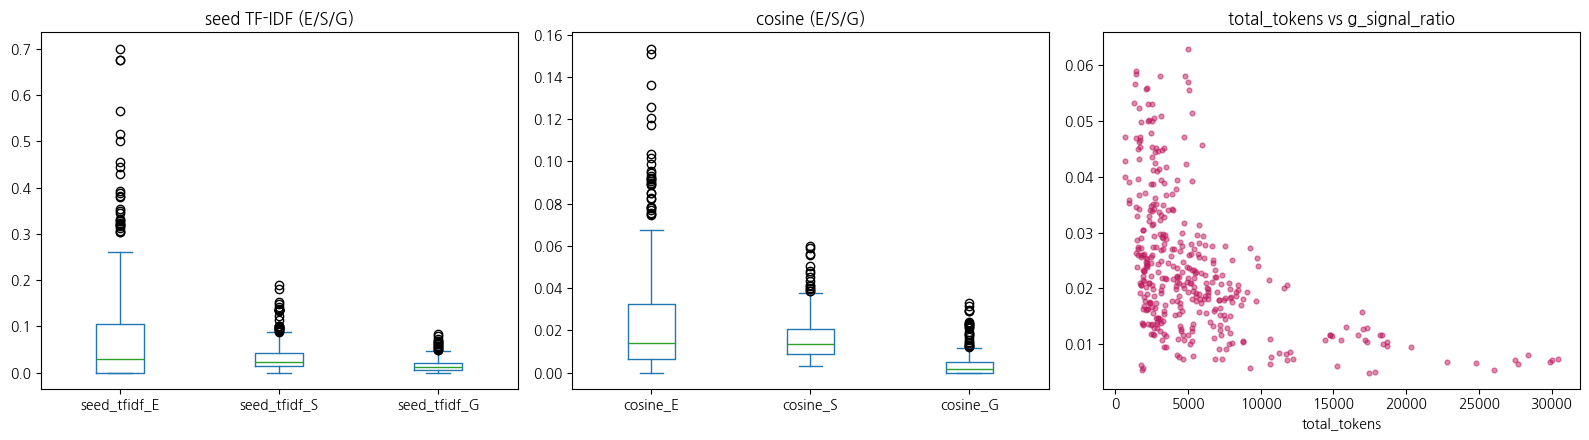

In [17]:
# ---- 4-3. KCGS 등급 join (stock_code × fiscal_year — 위반금지 #2) ----
features["stock_code"] = features["stock_code"].str.zfill(6)
grade_cols = ["stock_code","fiscal_year","esg_year","esg_grade","esg_grade_num",
              "e_grade_num","s_grade_num","g_grade_num"]
lg = lineage.copy(); lg["fiscal_year"] = lg["fiscal_year"].astype(int)
features = features.merge(lg[[c for c in grade_cols if c in lg.columns]],
                          on=["stock_code","fiscal_year"], how="left")
for c in ["esg_grade_num","e_grade_num","s_grade_num","g_grade_num"]:
    if c in features.columns:
        features[c] = pd.to_numeric(features[c], errors="coerce")
n_grade = features["esg_grade_num"].notna().sum()
print(f"feature 행 {len(features)} | KCGS 등급 매칭 {n_grade}")
features.to_parquet(OUT_DIR / "esg_features_integrated_v1.parquet")
features.to_csv(OUT_DIR / "esg_features_integrated_v1.csv", index=False, encoding="utf-8-sig")

# 시각화: 차원별 TF-IDF 분포 + signal_ratio
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
features[["seed_tfidf_E","seed_tfidf_S","seed_tfidf_G"]].plot(kind="box", ax=axes[0]); axes[0].set_title("seed TF-IDF (E/S/G)")
features[["cosine_E","cosine_S","cosine_G"]].plot(kind="box", ax=axes[1]); axes[1].set_title("cosine (E/S/G)")
axes[2].scatter(features["total_tokens"], features["g_signal_ratio"], s=12, alpha=.5, color="#be185d")
axes[2].set_title("total_tokens vs g_signal_ratio"); axes[2].set_xlabel("total_tokens")
plt.tight_layout(); plt.savefig(OUT_DIR / "fig_04_features.png", dpi=110, bbox_inches="tight"); plt.show()


## 5. 기본 통계·회귀

### What
feature가 KCGS 등급과 연관되는지 (1) **Spearman 순위상관 + Bootstrap 95% CI**, (2) **Mann-Whitney U**(고등급 vs 저등급)로 검증하고, (3) **OLS·Ordered Logit·Binary Logit** 3종 회귀를 비교합니다.

### Why
- **Spearman**: ESG 등급은 서열변수이므로 순위상관이 적합 (가이드 03 §3단계).
- **Bootstrap CI** (김지우 방식): CI가 0을 포함하지 않으면 강한 증거. p-value 보강.
- **Mann-Whitney U**: 고등급(A 이상)과 저등급 그룹의 feature 평균 차이 (가이드 03 line 192).
- **3종 회귀**: OLS(직관적 baseline)·Ordered(서열 보존)·Binary(A 이상 여부) — 팀 질문에 맞춰 선택 근거 기록 (가이드 03 §5단계).


In [18]:
# ---- 5-1. Spearman + Bootstrap 95% CI (김지우 방식) ----
ana = features[features["esg_grade_num"].notna()].copy()
N = len(ana)
print(f"분석 표본 N = {N} (KCGS 등급 매칭 firm-year)")

feat_list = ["seed_tfidf_E","seed_tfidf_S","seed_tfidf_G","expanded_tfidf_S","expanded_tfidf_G",
             "cosine_E","cosine_S","cosine_G","g_signal_ratio","esg_signal_ratio","total_tokens","specificity"]

def boot_ci(x, y, n_boot=400, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(x)); rhos = []
    for _ in range(n_boot):
        s = rng.choice(idx, len(idx), replace=True)
        if np.std(x.values[s]) > 0 and np.std(y.values[s]) > 0:
            rhos.append(spearmanr(x.values[s], y.values[s]).correlation)
    return (np.nanpercentile(rhos, 2.5), np.nanpercentile(rhos, 97.5)) if rhos else (np.nan, np.nan)

rows = []
for f in feat_list:
    rho, p = spearmanr(ana[f], ana["esg_grade_num"])
    lo, hi = boot_ci(ana[f], ana["esg_grade_num"])
    sig = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else ""
    rows.append({"feature": f, "rho": round(rho,3), "p": round(p,4),
                 "CI_lo": round(lo,3), "CI_hi": round(hi,3),
                 "CI_excl_0": (lo>0 or hi<0), "sig": sig})
sp = pd.DataFrame(rows).sort_values("rho", ascending=False)
print(sp.to_string(index=False))
sp.to_csv(OUT_DIR / "spearman_bootstrap.csv", index=False, encoding="utf-8-sig")


분석 표본 N = 381 (KCGS 등급 매칭 firm-year)


         feature    rho      p  CI_lo  CI_hi  CI_excl_0 sig
    total_tokens  0.654 0.0000  0.595  0.705       True ***
        cosine_S  0.401 0.0000  0.309  0.479       True ***
        cosine_E  0.346 0.0000  0.265  0.432       True ***
    seed_tfidf_E  0.318 0.0000  0.231  0.413       True ***
     specificity  0.267 0.0000  0.167  0.353       True ***
        cosine_G  0.247 0.0000  0.152  0.342       True ***
    seed_tfidf_G  0.210 0.0000  0.119  0.303       True ***
expanded_tfidf_G  0.210 0.0000  0.119  0.303       True ***
expanded_tfidf_S  0.139 0.0067  0.044  0.236       True  **
    seed_tfidf_S  0.131 0.0103  0.039  0.228       True   *
esg_signal_ratio -0.061 0.2312 -0.162  0.032      False    
  g_signal_ratio -0.067 0.1947 -0.166  0.028      False    


In [19]:
# ---- 5-2. Mann-Whitney U (고등급 A 이상 vs 저등급) ----
ana["high_grade"] = (ana["esg_grade_num"] >= 4).astype(int)  # A(4) 이상
print(f"고등급(A+) {ana['high_grade'].sum()} vs 저등급 {len(ana)-ana['high_grade'].sum()}")
mwu_rows = []
for f in feat_list:
    hi_g = ana[ana["high_grade"]==1][f]; lo_g = ana[ana["high_grade"]==0][f]
    if len(hi_g)>2 and len(lo_g)>2:
        u, p = mannwhitneyu(hi_g, lo_g, alternative="two-sided")
        mwu_rows.append({"feature": f, "고등급_평균": round(hi_g.mean(),4),
                         "저등급_평균": round(lo_g.mean(),4), "MWU_p": round(p,4),
                         "유의": "✓" if p<.05 else ""})
mwu = pd.DataFrame(mwu_rows)
print(mwu.to_string(index=False))


고등급(A+) 152 vs 저등급 229
         feature    고등급_평균    저등급_평균  MWU_p 유의
    seed_tfidf_E    0.1096    0.0634 0.0000  ✓
    seed_tfidf_S    0.0370    0.0300 0.0192  ✓
    seed_tfidf_G    0.0165    0.0141 0.0056  ✓
expanded_tfidf_S    0.0517    0.0494 0.0417  ✓
expanded_tfidf_G    0.0165    0.0141 0.0056  ✓
        cosine_E    0.0300    0.0204 0.0000  ✓
        cosine_S    0.0186    0.0144 0.0000  ✓
        cosine_G    0.0041    0.0032 0.0001  ✓
  g_signal_ratio    0.0224    0.0245 0.1423   
esg_signal_ratio    0.0243    0.0257 0.1535   
    total_tokens 8186.1645 3818.3712 0.0000  ✓
     specificity    0.0003    0.0002 0.0000  ✓


주 설명변수: cosine_S (Spearman 기준 자동 선택)

[OLS]
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.6124      0.774    -11.126      0.000     -10.134      -7.090
cosine_S      23.0622      6.661      3.462      0.001       9.964      36.160
log_tokens     1.2991      0.096     13.517      0.000       1.110       1.488

[Ordered Logit] β1(cosine_S)=29.188 p=0.0020



[Binary Logit] β1(cosine_S)=8.251 p=0.5052 pseudoR2=0.238

[회귀 3종 비교]
             모형  β1(main)      p    R2    AIC   N
            OLS    23.062 0.0006 0.406 1257.1 381
   OrderedLogit    29.188 0.0020   NaN 1104.7 381
BinaryLogit(A↑)     8.251 0.5052 0.238  396.3 381


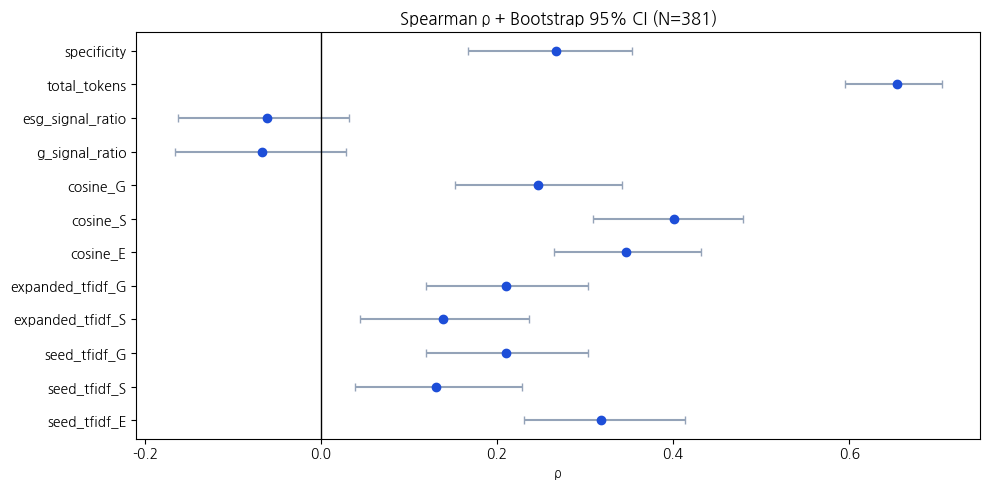

In [20]:
# ---- 5-3. 회귀 3종 (OLS / Ordered / Binary) ----
reg_summary = []
# 종속변수 후보: 가장 강한 feature 자동 선택 (유의 + |rho| 최대)
sig_feats = sp[(sp["p"]<.05) & (sp["feature"]!="total_tokens")]
main_feat = sig_feats.iloc[0]["feature"] if len(sig_feats) else "seed_tfidf_E"
print(f"주 설명변수: {main_feat} (Spearman 기준 자동 선택)\n")

d = ana.dropna(subset=[main_feat,"total_tokens","esg_grade_num"]).copy()
d["log_tokens"] = np.log1p(d["total_tokens"])

# OLS: esg_grade_num ~ main_feat + log_tokens (cheap-talk 통제)
Xo = sm.add_constant(d[[main_feat,"log_tokens"]]); yo = d["esg_grade_num"]
ols = sm.OLS(yo, Xo).fit()
reg_summary.append({"모형":"OLS", "β1(main)":round(ols.params[main_feat],3),
                    "p":round(ols.pvalues[main_feat],4), "R2":round(ols.rsquared,3),
                    "AIC":round(ols.aic,1), "N":int(ols.nobs)})
print("[OLS]"); print(ols.summary().tables[1])

# Ordered Logit
if HAS_ORDERED and d["esg_grade_num"].nunique() >= 3:
    try:
        om = OrderedModel(d["esg_grade_num"], d[[main_feat,"log_tokens"]], distr="logit").fit(method="bfgs", disp=False)
        reg_summary.append({"모형":"OrderedLogit", "β1(main)":round(om.params[main_feat],3),
                            "p":round(om.pvalues[main_feat],4), "R2":np.nan,
                            "AIC":round(om.aic,1), "N":int(d.shape[0])})
        print("\n[Ordered Logit] β1(%s)=%.3f p=%.4f" % (main_feat, om.params[main_feat], om.pvalues[main_feat]))
    except Exception as e:
        print("\n[Ordered Logit] 실패:", e)

# Binary Logit: A 이상 여부
Xb = sm.add_constant(d[[main_feat,"log_tokens"]]); yb = (d["esg_grade_num"]>=4).astype(int)
if yb.nunique()==2:
    try:
        bl = sm.Logit(yb, Xb).fit(disp=False)
        reg_summary.append({"모형":"BinaryLogit(A↑)", "β1(main)":round(bl.params[main_feat],3),
                            "p":round(bl.pvalues[main_feat],4), "R2":round(bl.prsquared,3),
                            "AIC":round(bl.aic,1), "N":int(bl.nobs)})
        print("\n[Binary Logit] β1(%s)=%.3f p=%.4f pseudoR2=%.3f" % (main_feat, bl.params[main_feat], bl.pvalues[main_feat], bl.prsquared))
    except Exception as e:
        print("\n[Binary Logit] 실패:", e)

reg_df = pd.DataFrame(reg_summary)
print("\n[회귀 3종 비교]"); print(reg_df.to_string(index=False))
reg_df.to_csv(OUT_DIR / "regression_3models.csv", index=False, encoding="utf-8-sig")

# 시각화: Spearman ρ + CI
fig, ax = plt.subplots(figsize=(10, 5))
spp = sp.set_index("feature").loc[feat_list]
ax.errorbar(spp["rho"], range(len(spp)),
            xerr=[spp["rho"]-spp["CI_lo"], spp["CI_hi"]-spp["rho"]],
            fmt="o", color="#1d4ed8", ecolor="#94a3b8", capsize=3)
ax.axvline(0, color="#000", lw=1)
ax.set_yticks(range(len(spp))); ax.set_yticklabels(spp.index)
ax.set_title(f"Spearman ρ + Bootstrap 95% CI (N={N})"); ax.set_xlabel("ρ")
plt.tight_layout(); plt.savefig(OUT_DIR / "fig_05_spearman_ci.png", dpi=110, bbox_inches="tight"); plt.show()


## 6. 알파분석 4종

회의에서 알파 주제를 모두 시도하기로 했습니다. 가이드 04 §3-1: "기법 난이도가 아니라 왜 필요한가·무엇을 더 확인했는가·어떤 한계가 남았는가"가 핵심.

1. **부호 역전 robustness** (김지우 발견 정식화) — 표본 크기별 ρ 변화 + 표집 편의 진단
2. **section_weighted** (II/IV/VI 가중) — 보고서 위치별 ESG 점수 변별력
3. **업종별 분해** — 업종이 교란변수인지
4. **cheap-talk 3종** — specificity/commitment/non-material로 verbosity 통제 강화


In [21]:
# ---- 6-1. 알파 ① 부호 역전 robustness (표본 크기별 ρ) ----
# 김지우 발견: 파일럿(소표본)에서 양 → 전체에서 음. 표집 편의 진단.
print("[알파 ① 부호 역전 robustness — 표본 크기별 Spearman ρ]")
target_feat = main_feat
sizes = sorted(set([10, 20, 30, 50, 100, N]))
sizes = [s for s in sizes if s <= N]
rng = np.random.default_rng(42)
rev_rows = []
for sz in sizes:
    rhos = []
    for _ in range(120):
        sub = ana.sample(sz, random_state=rng.integers(1e9))
        if sub[target_feat].std() > 0:
            rhos.append(spearmanr(sub[target_feat], sub["esg_grade_num"]).correlation)
    rev_rows.append({"표본크기": sz, "ρ_평균": round(np.nanmean(rhos),3),
                     "ρ_표준편차": round(np.nanstd(rhos),3),
                     "양의비율%": round(np.mean(np.array(rhos)>0)*100,0)})
rev_df = pd.DataFrame(rev_rows)
print(rev_df.to_string(index=False))
print(f"\n해석: 소표본일수록 ρ 변동성↑. 전체 N={N}의 ρ가 안정적 추정. "
      f"(김지우 발견: 상위 대형주 편중 파일럿은 spurious +ve 위험)")


[알파 ① 부호 역전 robustness — 표본 크기별 Spearman ρ]


 표본크기  ρ_평균  ρ_표준편차  양의비율%
   10 0.317   0.332   82.0
   20 0.379   0.171   98.0
   30 0.376   0.147   99.0
   50 0.393   0.121  100.0
  100 0.390   0.074  100.0
  381 0.401   0.000  100.0

해석: 소표본일수록 ρ 변동성↑. 전체 N=381의 ρ가 안정적 추정. (김지우 발견: 상위 대형주 편중 파일럿은 spurious +ve 위험)


In [22]:
# ---- 6-2. 알파 ② section_weighted (II/IV/VI 가중) ----
# 섹션별 글자수를 가중치로 ESG 신호를 재구성. VI(거버넌스)는 모든 firm 공통이라 변별력↓ 가설.
print("[알파 ② section_weighted — 섹션별 분량과 등급 상관]")
sec_rows = []
for r in succ.itertuples():
    key = f"{r.stock_code}_{int(r.fiscal_year)}"
    sec_rows.append({"stock_code": r.stock_code, "fiscal_year": int(r.fiscal_year),
                     "ch_II": float(getattr(r,"section_chars_II",0) or 0),
                     "ch_IV": float(getattr(r,"section_chars_IV",0) or 0),
                     "ch_VI": float(getattr(r,"section_chars_VI",0) or 0)})
secdf = pd.DataFrame(sec_rows)
secdf["stock_code"] = secdf["stock_code"].str.zfill(6)
sm2 = secdf.merge(ana[["stock_code","fiscal_year","esg_grade_num"]], on=["stock_code","fiscal_year"], how="inner")
for col in ["ch_II","ch_IV","ch_VI"]:
    if sm2[col].std() > 0:
        rho, p = spearmanr(sm2[col], sm2["esg_grade_num"])
        print(f"  {col} ↔ esg_grade: ρ={rho:.3f}, p={p:.4f}")
print("  해석: 각 섹션 분량(=공시량)과 등급의 관계. VI 변별력 점검.")


[알파 ② section_weighted — 섹션별 분량과 등급 상관]
  ch_II ↔ esg_grade: ρ=0.583, p=0.0000
  ch_IV ↔ esg_grade: ρ=0.593, p=0.0000
  ch_VI ↔ esg_grade: ρ=0.521, p=0.0000
  해석: 각 섹션 분량(=공시량)과 등급의 관계. VI 변별력 점검.


In [23]:
# ---- 6-3. 알파 ③ 업종별 분해 ----
print("[알파 ③ 업종별 분해 — N>=10 업종만]")
if "industry" in lineage.columns:
    ind = lineage[["stock_code","fiscal_year","industry"]].copy()
    ind["fiscal_year"] = ind["fiscal_year"].astype(int)
    ind["stock_code"] = ind["stock_code"].str.zfill(6)
    aind = ana.merge(ind, on=["stock_code","fiscal_year"], how="left")
    vc = aind["industry"].value_counts()
    big_inds = vc[vc>=10].index.tolist()
    print(f"  N>=10 업종: {big_inds}")
    for g in big_inds:
        sub = aind[aind["industry"]==g]
        if sub[main_feat].std()>0:
            rho,p = spearmanr(sub[main_feat], sub["esg_grade_num"])
            print(f"  [{g}] N={len(sub)} | {main_feat}↔grade ρ={rho:.3f} p={p:.4f}")
    if not big_inds:
        print("  N>=10 업종 없음 — 표본 더 필요")
else:
    print("  industry 컬럼 없음")


[알파 ③ 업종별 분해 — N>=10 업종만]
  N>=10 업종: ['금융지주']
  [금융지주] N=15 | cosine_S↔grade ρ=0.622 p=0.0133


In [24]:
# ---- 6-4. 알파 ④ cheap-talk 3종 통제 ----
# total_tokens(verbosity) + specificity(숫자) + non-material(boilerplate 비율) 통제 후 신호 잔존 여부.
print("[알파 ④ cheap-talk 3종 통제 OLS]")
d2 = ana.dropna(subset=[main_feat,"esg_grade_num"]).copy()
d2["log_tokens"] = np.log1p(d2["total_tokens"])
# commitment proxy: specificity (숫자 약속), non_material proxy: 1 - esg_signal_ratio
d2["non_material"] = 1 - d2["esg_signal_ratio"]
Xc = sm.add_constant(d2[[main_feat,"log_tokens","specificity","non_material"]])
m = sm.OLS(d2["esg_grade_num"], Xc).fit()
print(m.summary().tables[1])
b, p = m.params[main_feat], m.pvalues[main_feat]
print(f"\n해석: cheap-talk 3종(verbosity·specificity·non-material) 통제 후 "
      f"{main_feat} β={b:.3f}, p={p:.4f}")
print("  → 통제 후에도 유의하면 텍스트 신호가 단순 장황함 이상. 비유의면 cheap-talk 가설 강화.")


[알파 ④ cheap-talk 3종 통제 OLS]
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           30.4490      6.239      4.880      0.000      18.181      42.717
cosine_S        14.2642      6.627      2.153      0.032       1.235      27.294
log_tokens       1.6348      0.107     15.269      0.000       1.424       1.845
specificity    -26.1602    164.513     -0.159      0.874    -349.641     297.320
non_material   -42.7904      6.788     -6.304      0.000     -56.137     -29.444

해석: cheap-talk 3종(verbosity·specificity·non-material) 통제 후 cosine_S β=14.264, p=0.0320
  → 통제 후에도 유의하면 텍스트 신호가 단순 장황함 이상. 비유의면 cheap-talk 가설 강화.


## 7. 종합 결론 + 한계

### 결과 요약
아래 셀에서 핵심 수치를 자동 출력합니다. 회의(5/23)에서 이 결과를 팀 결과물과 비교해 최종 분석 파일의 토대를 잡습니다.

### 한계 (가이드 04 §4 — 인과 아닌 연관)
- **표본**: 최대 381 firm-year는 수업용 pilot panel. KCGS 전체 대표표본 아님.
- **cheap-talk**: 공시 언어 강도 ≠ 실제 ESG 성과. verbosity 통제해도 완전 분리 어려움.
- **timing**: `esg_year = fiscal_year + 1` 정렬은 인과 식별 아님.
- **분석기**: PRIMARY 1종 결과. §2 robust 검증으로 선정했으나 분석기 의존성 잔존.
- **고정효과 미통제**: 기업·연도 FE 미투입 (알파 후보).
- **결과는 연관성**으로만 해석. "언어가 등급을 결정/예측"이 아님.


In [25]:
# ---- 7-1. 종합 결과 자동 요약 ----
print("="*60)
print("  ESG DART 통합 분석 v1 — 종합 요약")
print("="*60)
print(f"수집: {len(meta_df)} 시도 → SUCCESS {len(succ)} ({len(succ)/len(meta_df)*100:.1f}%)")
print(f"분석기 PRIMARY: {USE} (seed 보존율 {cmp_df.loc[USE,'seed_보존율%']:.0f}%)")
print(f"분석 표본 N(등급 매칭): {N}")
print(f"\n[상위 유의 feature (Spearman)]")
print(sp[sp['p']<.05][['feature','rho','p','CI_lo','CI_hi','sig']].to_string(index=False))
print(f"\n[회귀 3종]")
print(reg_df.to_string(index=False))
print(f"\n[알파 ① 부호 역전 — 표본 크기별 ρ]")
print(rev_df.to_string(index=False))
print("\n>>> 회의(5/23) 안건: 위 결과 + 팀 결과물 비교 → 최종 분석 파일 토대 + 역할 분담")


  ESG DART 통합 분석 v1 — 종합 요약
수집: 381 시도 → SUCCESS 381 (100.0%)
분석기 PRIMARY: Kiwi (seed 보존율 87%)
분석 표본 N(등급 매칭): 381

[상위 유의 feature (Spearman)]
         feature   rho      p  CI_lo  CI_hi sig
    total_tokens 0.654 0.0000  0.595  0.705 ***
        cosine_S 0.401 0.0000  0.309  0.479 ***
        cosine_E 0.346 0.0000  0.265  0.432 ***
    seed_tfidf_E 0.318 0.0000  0.231  0.413 ***
     specificity 0.267 0.0000  0.167  0.353 ***
        cosine_G 0.247 0.0000  0.152  0.342 ***
    seed_tfidf_G 0.210 0.0000  0.119  0.303 ***
expanded_tfidf_G 0.210 0.0000  0.119  0.303 ***
expanded_tfidf_S 0.139 0.0067  0.044  0.236  **
    seed_tfidf_S 0.131 0.0103  0.039  0.228   *

[회귀 3종]
             모형  β1(main)      p    R2    AIC   N
            OLS    23.062 0.0006 0.406 1257.1 381
   OrderedLogit    29.188 0.0020   NaN 1104.7 381
BinaryLogit(A↑)     8.251 0.5052 0.238  396.3 381

[알파 ① 부호 역전 — 표본 크기별 ρ]
 표본크기  ρ_평균  ρ_표준편차  양의비율%
   10 0.317   0.332   82.0
   20 0.379   0.171   98.0
   30 0.376   